# Plot

> A collection of plot functions

## Setup

In [ ]:
#| default_exp core.plot

In [ ]:
#| export
import pandas as pd, seaborn as sns
from fastcore.meta import delegates
from matplotlib import pyplot as plt

# # kdock
# from kdock.core.data import *

# dimentional reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

In [ ]:
#| hide
pd.set_option('display.max_rows', 5)
pd.set_option('display.max_columns', 100) # show all columns

## Dimensionality reduction

In [ ]:
#| export
def reduce_feature(data, # df or numpy array
                   method='pca', # dimensionality reduction method, accept both capital and lower case
                   complexity=20, # None for PCA; perfplexity for TSNE, recommend: 30; n_neigbors for UMAP, recommend: 15
                   n=2, # n_components
                   seed: int=123, # seed for random_state
                   **kwargs, # arguments from PCA, TSNE, or UMAP depends on which method to use
                  ):
    
    "Reduce the dimensionality given a dataframe of values"
    
    method = method.lower()
    assert method in ['pca','tsne','umap'], "Please choose a method among PCA, TSNE, and UMAP"

    if method == 'pca':
        reducer = PCA(n_components=n, random_state=seed,**kwargs)
    elif method == 'tsne':
        reducer = TSNE(n_components=n,
                       random_state=seed, 
                       perplexity = complexity, # default from official is 30 
                      **kwargs)
    elif method == 'umap':
        reducer = UMAP(n_components=n, 
                       random_state=seed, 
                       n_neighbors=complexity, # default from official is 15, try 15-200
                      **kwargs)
    else:
        raise ValueError('Invalid method specified')

    proj = reducer.fit_transform(data)
    embedding_df = pd.DataFrame(proj).set_index(data.index) if isinstance(data,pd.DataFrame) else pd.DataFrame(proj)
    embedding_df.columns = [f"{method.upper()}{i}" for i in range(1, n + 1)]

    return embedding_df

In [ ]:
# morgan fingerprints
df = pd.read_csv('files/morgan.csv')
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
299,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
pca = reduce_feature(df,'pca',n=10)
pca

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10
0,5.055364,-0.201475,0.017985,-1.484066,1.548818,0.998801,-1.959704,-1.446077,2.579568,0.791852
1,0.720893,0.104023,3.616964,0.774077,0.262882,-0.813578,0.194586,0.606086,0.337897,1.006187
...,...,...,...,...,...,...,...,...,...,...
298,-0.911653,-0.834387,0.054771,-0.141513,-0.385500,0.036934,0.139089,-0.157255,-0.316494,-0.042620
299,-0.506653,-0.217700,-0.309063,0.005900,-0.275369,-0.652045,-0.151574,0.838589,-0.281150,-0.323430


## 2d plot

In [ ]:
#| export
def set_sns():
    sns.set(rc={"figure.dpi":300, 'savefig.dpi':300})
    sns.set_context('notebook')
    sns.set_style("ticks")

In [ ]:
set_sns()

In [ ]:
#| export
@delegates(sns.scatterplot)
def plot_2d(X: pd.DataFrame, # a dataframe that has first column to be x, and second column to be y
            **kwargs, # arguments for sns.scatterplot
            ):
    "Make 2D plot from a dataframe that has first column to be x, and second column to be y"
    plt.figure(figsize=(7,7))
    sns.scatterplot(data = X,x=X.columns[0],y=X.columns[1],alpha=0.7,**kwargs)

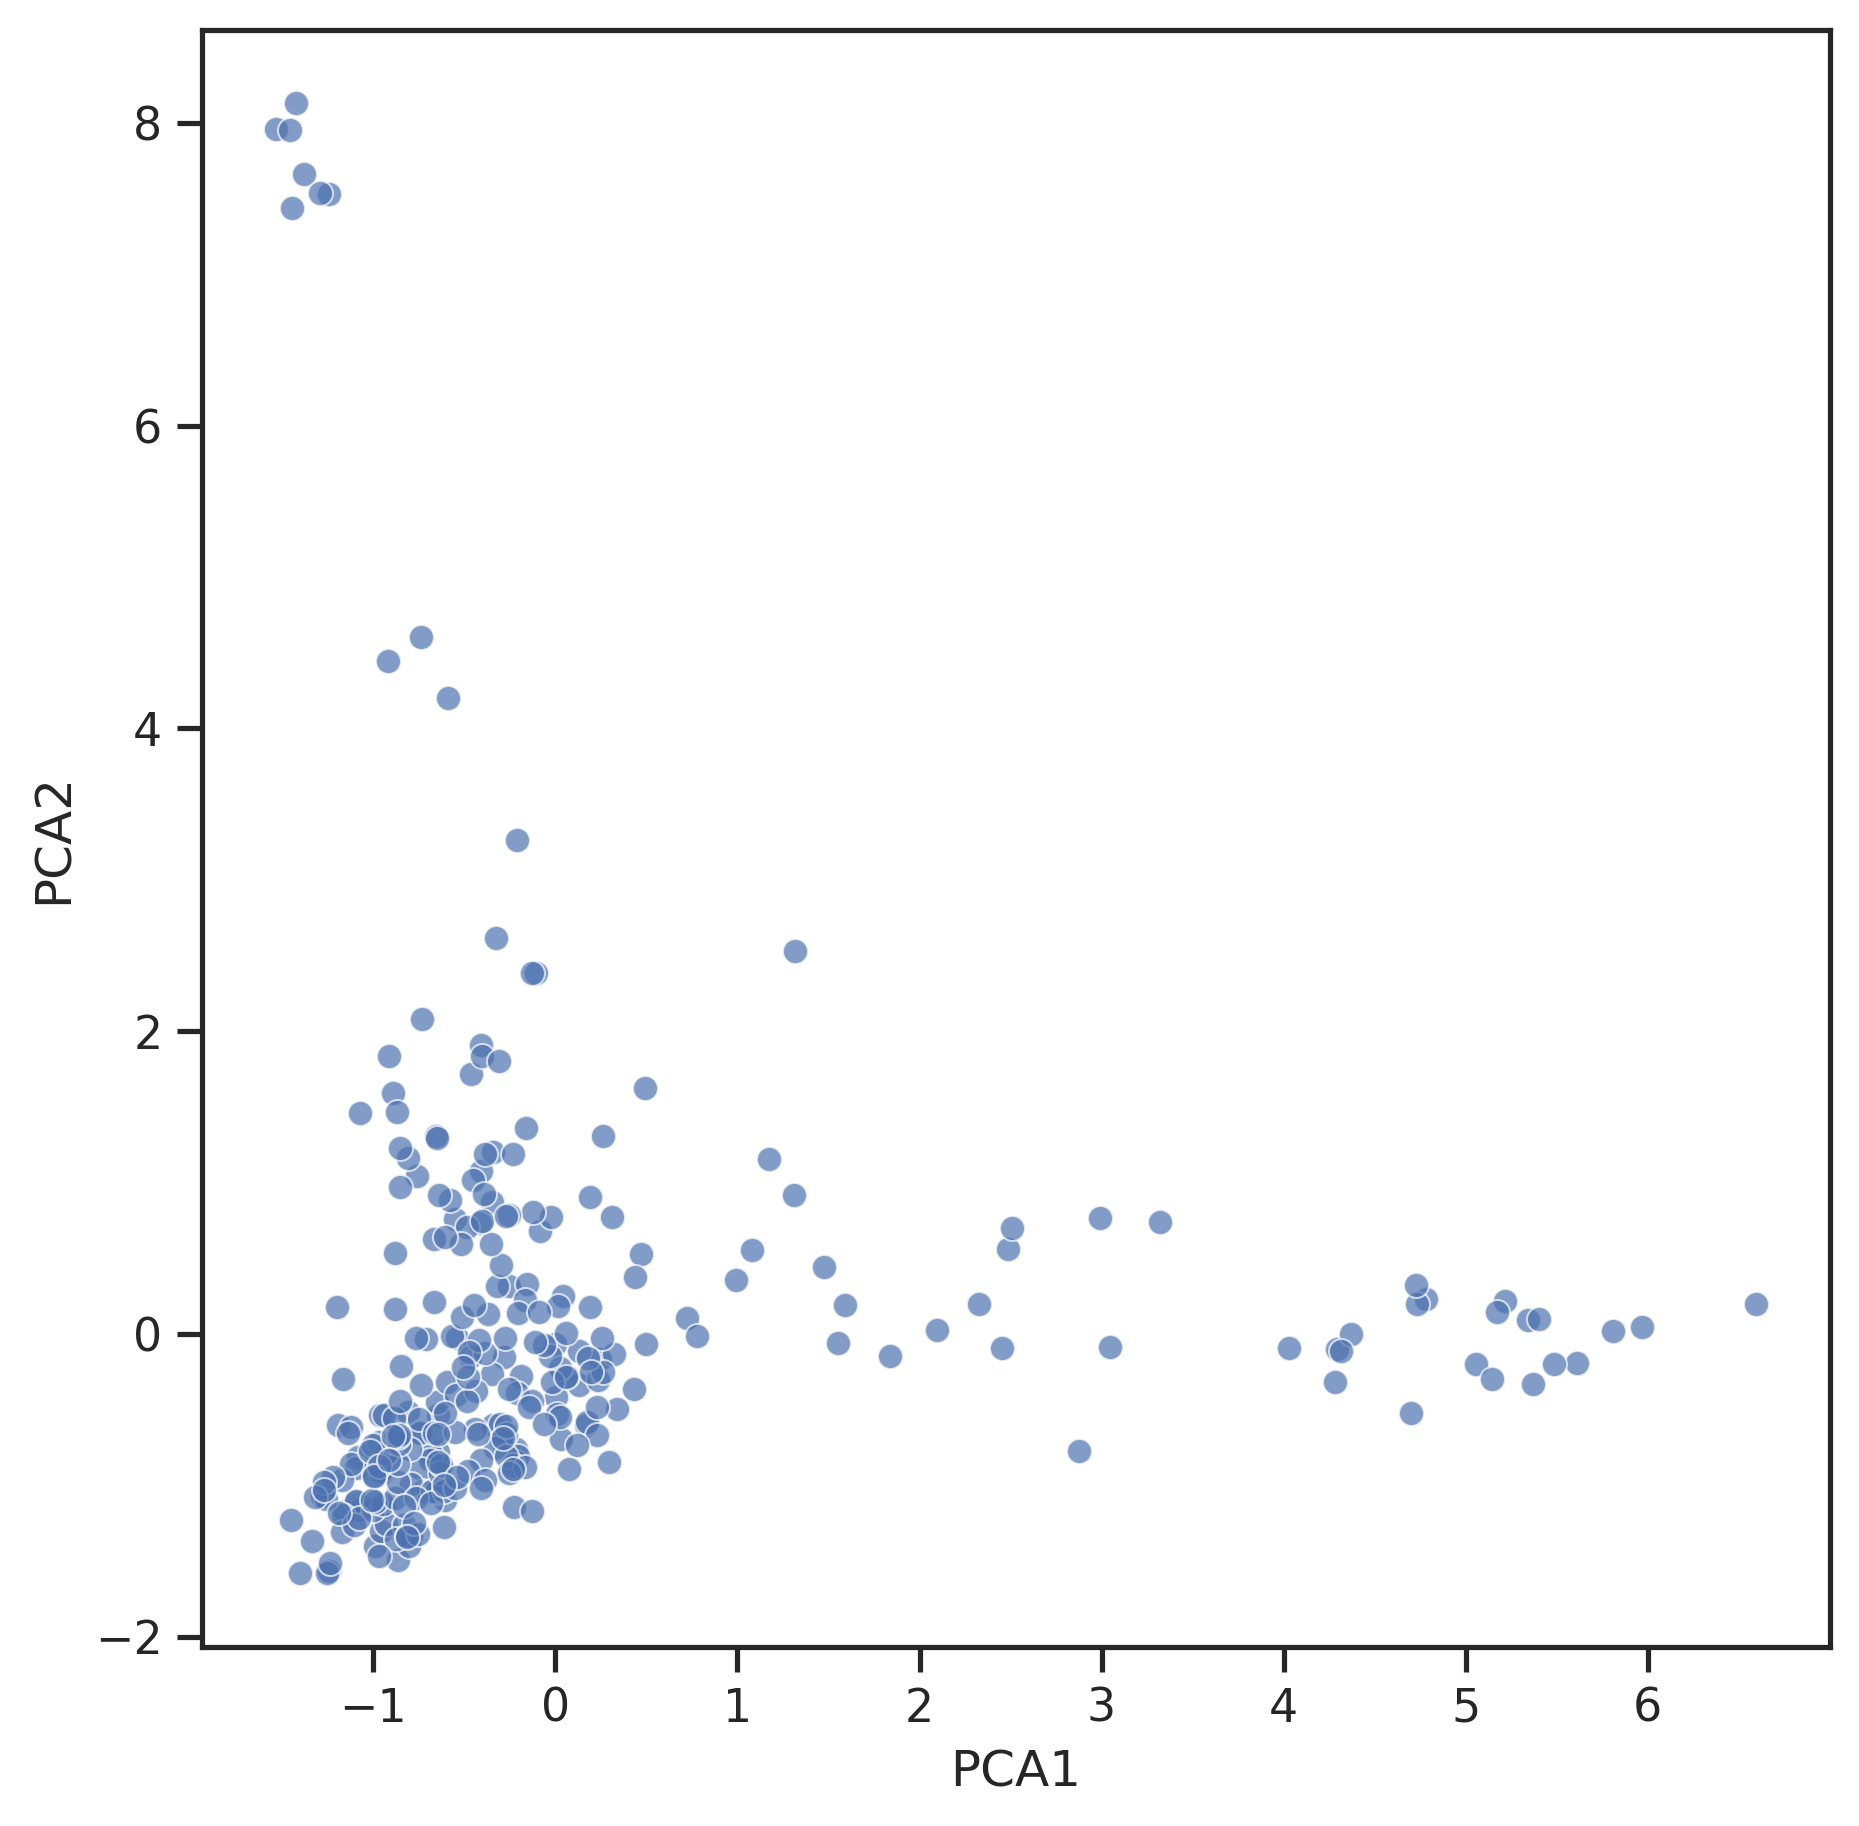

In [ ]:
plot_2d(pca.iloc[:,:2])

In [ ]:
#| export
def plot_corr(x,#a column of df
              y,#a column of df
              xlabel=None,# x axis label
              ylabel=None,# y axis label
              order=3, # polynomial level, if straight, order=1 
             ):
    sns.regplot(x=x,
            y=y,
            order=order,
            line_kws={'color': 'gray'}
           )
    
    if xlabel is not None:
        plt.xlabel(xlabel)
        
    if ylabel is not None:
        plt.ylabel(ylabel)
    # plt.text(x=0.8, y=0.1, s=f'Spearman: {correlation:.2f}', transform=plt.gca().transAxes, ha='center', va='center');

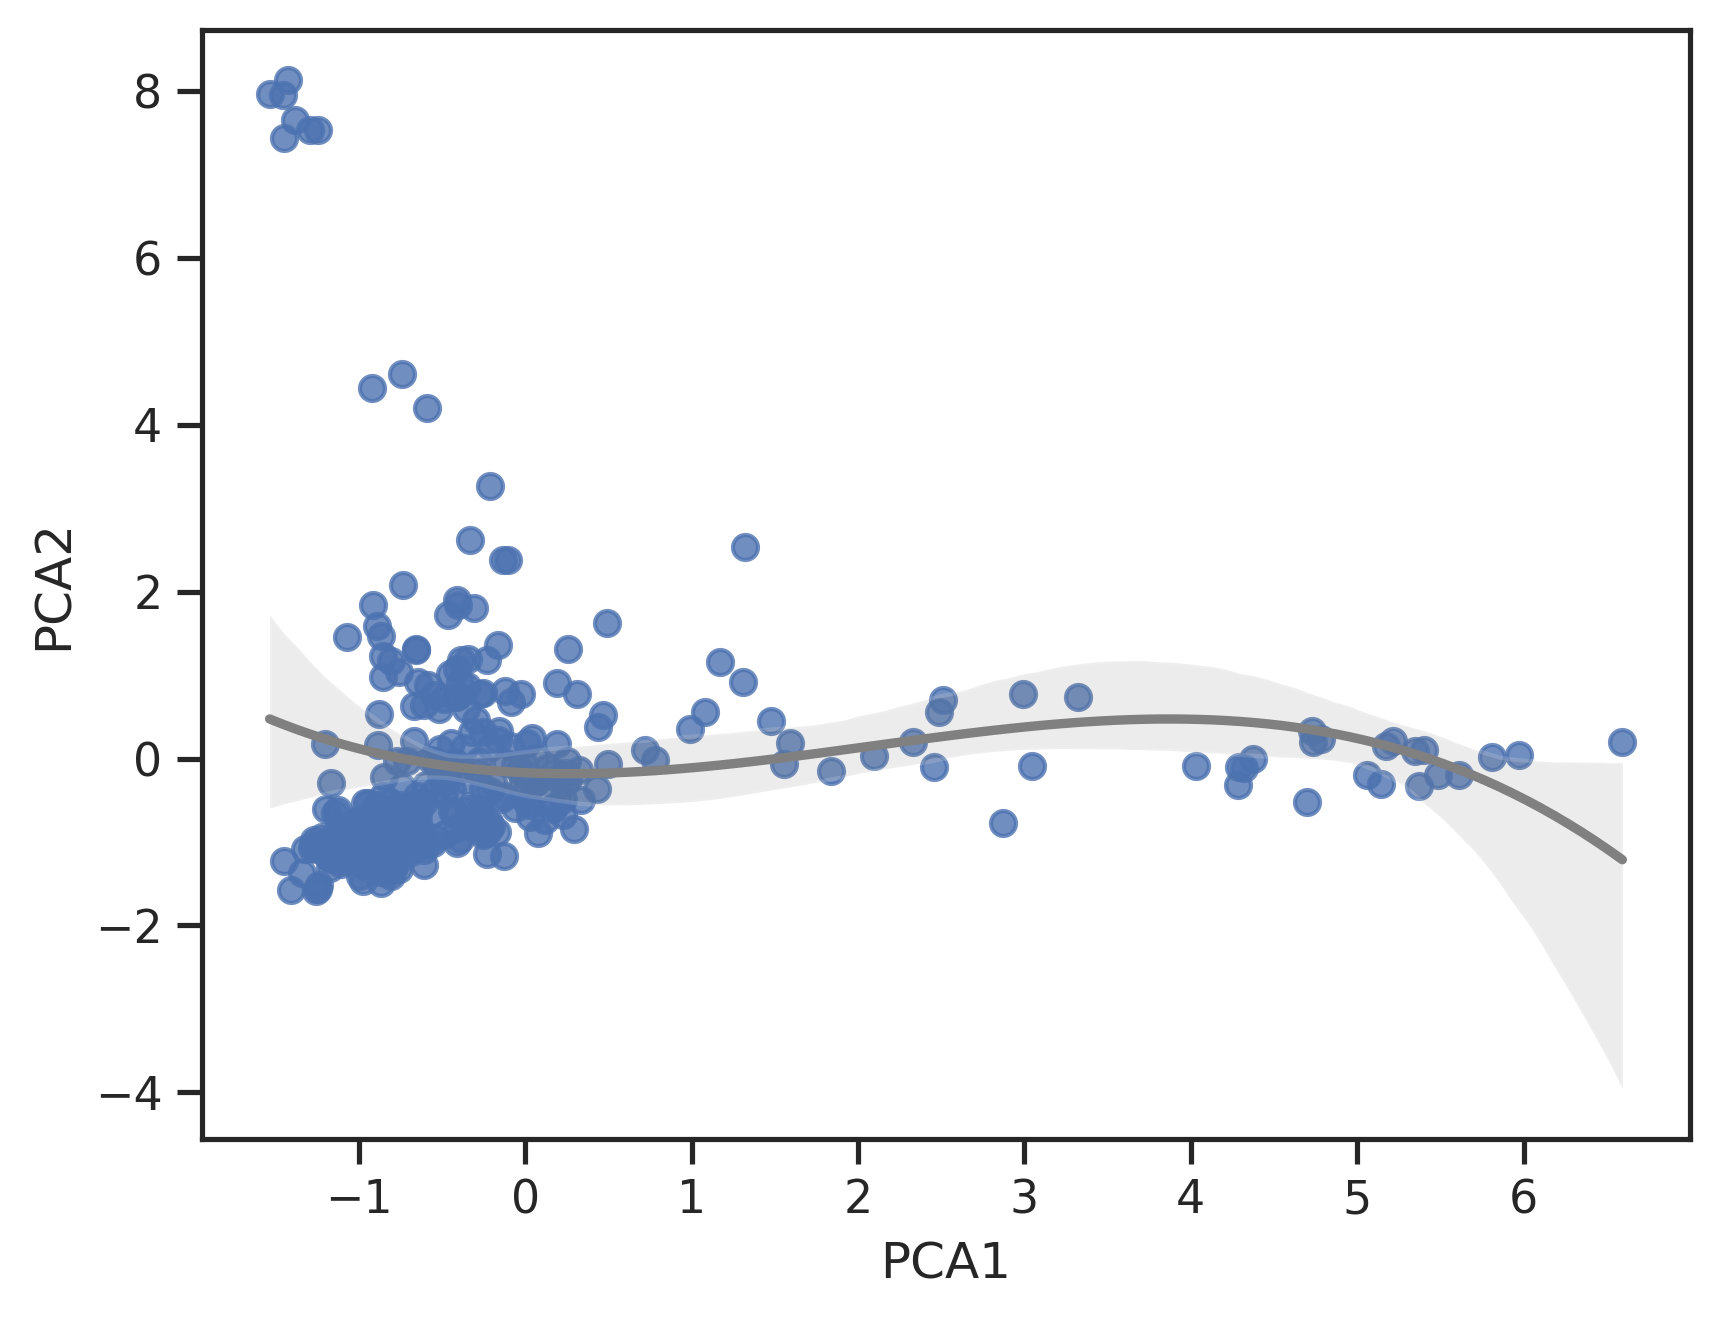

In [ ]:
plot_corr(pca.PCA1,pca.PCA2)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()